# Generate report figures from experiment artifacts

This notebook creates the two result figures required by `outputs/final_report.tex`:

1. Validation mAP comparison for teacher, student baseline and student KD.
2. Student KD training curves for loss components and mAP over epochs.

Data sources are kept explicit: `reports/benchmark/quality.csv` for the final validation comparison and `model_artifacts/student_kd_best.pt` (`train_results`) for the per-epoch curves.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
import torch


def find_project_root() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (candidate / "reports/benchmark/quality.csv").exists() and (candidate / "model_artifacts/student_kd_best.pt").exists():
            return candidate
    raise FileNotFoundError("Run this notebook from inside hpc_nhom1_code or restore the benchmark/model artifacts.")


ROOT = find_project_root()
QUALITY_CSV = ROOT / "reports/benchmark/quality.csv"
KD_CHECKPOINT = ROOT / "model_artifacts/student_kd_best.pt"
FIGURE_DIR = ROOT / "outputs/figures"
HISTORY_CSV = ROOT / "reports/benchmark/student_kd_training_history.csv"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

COLORS = {"teal": "#0F6A72", "orange": "#D88734", "blue": "#3274A1", "gray": "#6B7280"}
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
})

print(f"Project root: {ROOT}")
print(f"Figure output: {FIGURE_DIR}")

Project root: /Users/anhoaithai/Documents/AHT/2. AREAS/UEH/Kì 6/Tính toán hiệu suất cao/Project/hpc_nhom1_code
Figure output: /Users/anhoaithai/Documents/AHT/2. AREAS/UEH/Kì 6/Tính toán hiệu suất cao/Project/hpc_nhom1_code/outputs/figures


## 1. Validation mAP comparison

The comparison uses the unified validation run recorded in `quality.csv`, rather than training-time metrics from checkpoints.

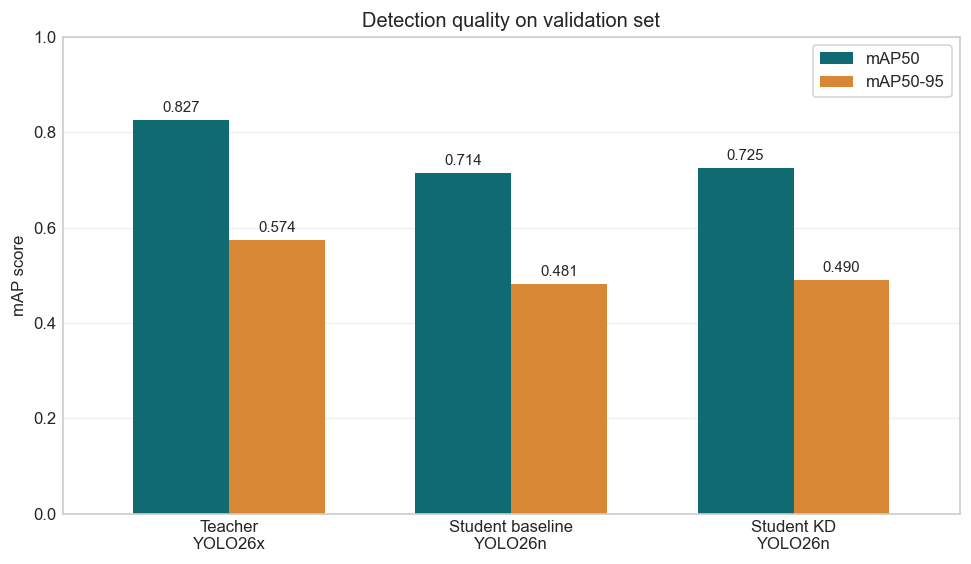

Saved: /Users/anhoaithai/Documents/AHT/2. AREAS/UEH/Kì 6/Tính toán hiệu suất cao/Project/hpc_nhom1_code/outputs/figures/map_comparison.png


,model,map50,map5095
0,teacher,0.8269,0.5737
1,student_baseline,0.7140,0.4809
2,student_kd,0.7250,0.4899


In [2]:
quality = pd.read_csv(QUALITY_CSV)
required_columns = {"model", "map50", "map5095"}
missing_columns = required_columns.difference(quality.columns)
if missing_columns:
    raise ValueError(f"Missing columns in {QUALITY_CSV}: {sorted(missing_columns)}")

model_order = ["teacher", "student_baseline", "student_kd"]
model_labels = {
    "teacher": "Teacher\nYOLO26x",
    "student_baseline": "Student baseline\nYOLO26n",
    "student_kd": "Student KD\nYOLO26n",
}
quality = quality.set_index("model").loc[model_order].reset_index()

ax = quality.plot(
    x="model",
    y=["map50", "map5095"],
    kind="bar",
    color=[COLORS["teal"], COLORS["orange"]],
    width=0.68,
    figsize=(8.2, 4.8),
)
ax.set_title("Detection quality on validation set")
ax.set_xlabel("")
ax.set_ylabel("mAP score")
ax.set_ylim(0, 1.0)
ax.set_xticklabels([model_labels[m] for m in model_order], rotation=0)
ax.legend(["mAP50", "mAP50-95"], frameon=True, loc="upper right")
ax.grid(axis="x", visible=False)
ax.grid(axis="y", alpha=0.3)
for bars in ax.containers:
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)

fig = ax.get_figure()
fig.tight_layout()
map_path = FIGURE_DIR / "map_comparison.png"
fig.savefig(map_path, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved: {map_path}")
quality[["model", "map50", "map5095"]]

## 2. Student KD loss and mAP by epoch

Ultralytics stores the original epoch-by-epoch `train_results` dictionary in the saved checkpoint. The plot below reads that history directly. The DFL series is placed on a secondary axis because its scale is much smaller than box and classification losses.

In [3]:
checkpoint = torch.load(KD_CHECKPOINT, map_location="cpu", weights_only=False)
history = pd.DataFrame(checkpoint.get("train_results", {}))
history_columns = {
    "epoch", "train/box_loss", "train/cls_loss", "train/dfl_loss",
    "metrics/mAP50(B)", "metrics/mAP50-95(B)",
}
missing_columns = history_columns.difference(history.columns)
if history.empty or missing_columns:
    raise ValueError(f"Checkpoint does not contain complete per-epoch history: {sorted(missing_columns)}")

history.to_csv(HISTORY_CSV, index=False)
print(f"Extracted {len(history)} epochs from {KD_CHECKPOINT.name}")
print(f"Saved auditable history table: {HISTORY_CSV}")
history.tail(3)

Extracted 30 epochs from student_kd_best.pt
Saved auditable history table: /Users/anhoaithai/Documents/AHT/2. AREAS/UEH/Kì 6/Tính toán hiệu suất cao/Project/hpc_nhom1_code/reports/benchmark/student_kd_training_history.csv


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
27,28,906.256,1.29160,0.98012,0.00438,0.72998,0.66830,0.72290,0.48719,1.23139,0.86754,0.00419,0.000121,0.000121,0.000121
28,29,937.088,1.27108,0.98265,0.00431,0.74138,0.67693,0.72368,0.48905,1.23308,0.87188,0.00417,0.000084,0.000084,0.000084
29,30,967.585,1.28349,0.95976,0.00430,0.73571,0.67650,0.72414,0.49000,1.22927,0.86071,0.00416,0.000048,0.000048,0.000048


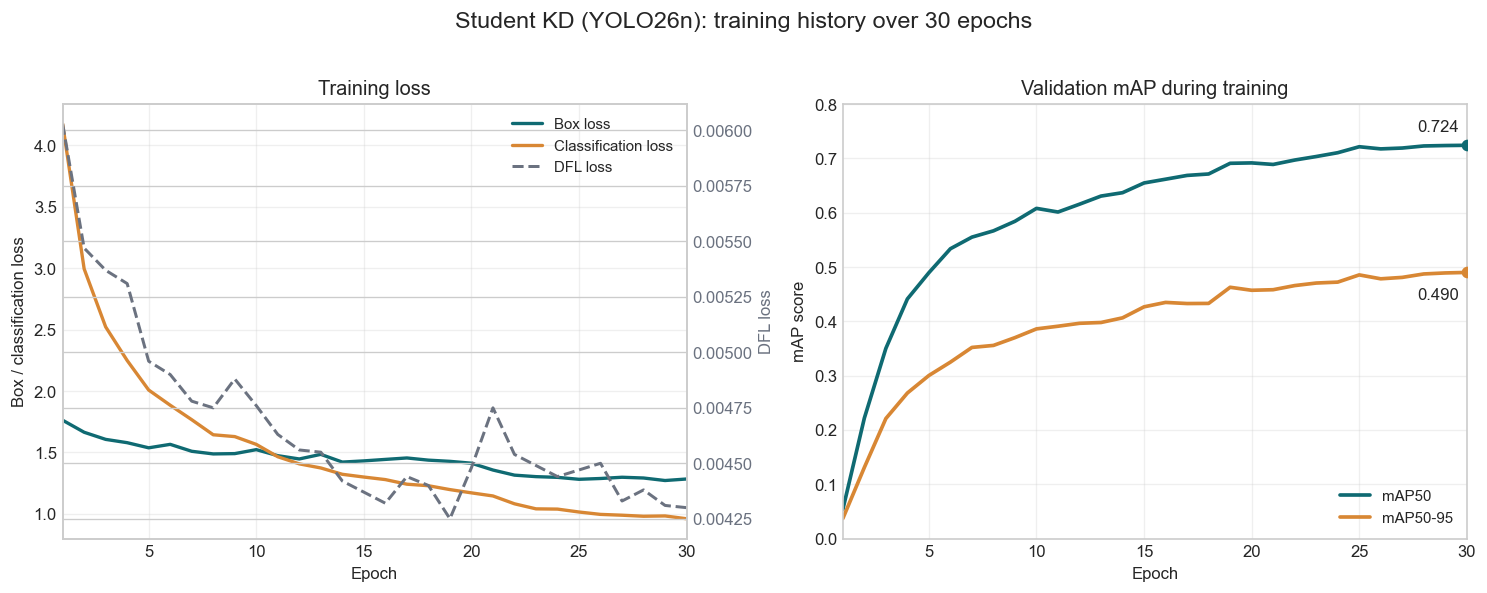

Saved: /Users/anhoaithai/Documents/AHT/2. AREAS/UEH/Kì 6/Tính toán hiệu suất cao/Project/hpc_nhom1_code/outputs/figures/student_kd_results.png


In [4]:
fig, (ax_loss, ax_map) = plt.subplots(1, 2, figsize=(12.5, 4.8))

epochs = history["epoch"]
ax_loss.plot(epochs, history["train/box_loss"], color=COLORS["teal"], linewidth=2.0, label="Box loss")
ax_loss.plot(epochs, history["train/cls_loss"], color=COLORS["orange"], linewidth=2.0, label="Classification loss")
ax_loss.set_title("Training loss")
ax_loss.set_xlabel("Epoch")
ax_loss.set_ylabel("Box / classification loss")
ax_loss.set_xlim(1, int(epochs.max()))
ax_loss.grid(alpha=0.3)

ax_dfl = ax_loss.twinx()
ax_dfl.plot(epochs, history["train/dfl_loss"], color=COLORS["gray"], linewidth=1.8, linestyle="--", label="DFL loss")
ax_dfl.set_ylabel("DFL loss", color=COLORS["gray"])
ax_dfl.tick_params(axis="y", labelcolor=COLORS["gray"])
loss_handles, loss_labels = ax_loss.get_legend_handles_labels()
dfl_handles, dfl_labels = ax_dfl.get_legend_handles_labels()
ax_loss.legend(loss_handles + dfl_handles, loss_labels + dfl_labels, loc="upper right", fontsize=9)

ax_map.plot(epochs, history["metrics/mAP50(B)"], color=COLORS["teal"], linewidth=2.2, label="mAP50")
ax_map.plot(epochs, history["metrics/mAP50-95(B)"], color=COLORS["orange"], linewidth=2.2, label="mAP50-95")
ax_map.scatter(epochs.iloc[-1], history["metrics/mAP50(B)"].iloc[-1], color=COLORS["teal"], zorder=3)
ax_map.scatter(epochs.iloc[-1], history["metrics/mAP50-95(B)"].iloc[-1], color=COLORS["orange"], zorder=3)
ax_map.annotate(f"{history['metrics/mAP50(B)'].iloc[-1]:.3f}", (epochs.iloc[-1], history["metrics/mAP50(B)"].iloc[-1]), xytext=(-30, 8), textcoords="offset points")
ax_map.annotate(f"{history['metrics/mAP50-95(B)'].iloc[-1]:.3f}", (epochs.iloc[-1], history["metrics/mAP50-95(B)"].iloc[-1]), xytext=(-30, -16), textcoords="offset points")
ax_map.set_title("Validation mAP during training")
ax_map.set_xlabel("Epoch")
ax_map.set_ylabel("mAP score")
ax_map.set_xlim(1, int(epochs.max()))
ax_map.set_ylim(0, 0.8)
ax_map.grid(alpha=0.3)
ax_map.legend(loc="lower right", fontsize=9)

fig.suptitle("Student KD (YOLO26n): training history over 30 epochs", fontsize=14, y=1.02)
fig.tight_layout()
curve_path = FIGURE_DIR / "student_kd_results.png"
fig.savefig(curve_path, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved: {curve_path}")

## LaTeX replacements

Replace the two placeholders in `outputs/final_report.tex` with:

```tex
\anhthat{0.90}{map_comparison.png}{fig:mapchart}{So sánh mAP50 và mAP50--95 giữa teacher, student baseline và student KD.}

\anhthat{0.98}{student_kd_results.png}{fig:trainingcurve}{Đường cong huấn luyện student KD: loss và mAP theo epoch.}
```
